# 06 — O2 : sécurité (national)

Ce notebook **montre** les données de O2. Il ne produit aucun chiffre du 06 : ces chiffres viennent des CSV écrits par `scripts/exploration_06.py` (`data/analysis/06_exploration/`) et des tables du 05 (R-19). Il n'applique aucun seuil du 02, ne classe pas et ne calcule aucun score. Un écart est décrit, pas expliqué ; une date de la chronologie est une coïncidence, pas une cause (H1).

**Ce qu'on regarde** : accidents constatés, tués et blessés (2010–2024), tués et blessés pour 100 accidents, les taux par habitant et par véhicule, les repères de l'OMS et la part des tués par type d'usager en 2021. Les accidents ne sont publiés qu'au niveau national (écart 1).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_06 import *
appliquer_style()
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

In [2]:
d3 = lire("D3_accidents").pivot(index="Année", columns="Mesure", values="Valeur")
MESURES = ["Accidents constatés", "Tués", "Blessés"]

## Accidents constatés, tués, blessés (O2-01)

Trois panneaux, un axe chacun. Cercles : variations atypiques (06 §4).

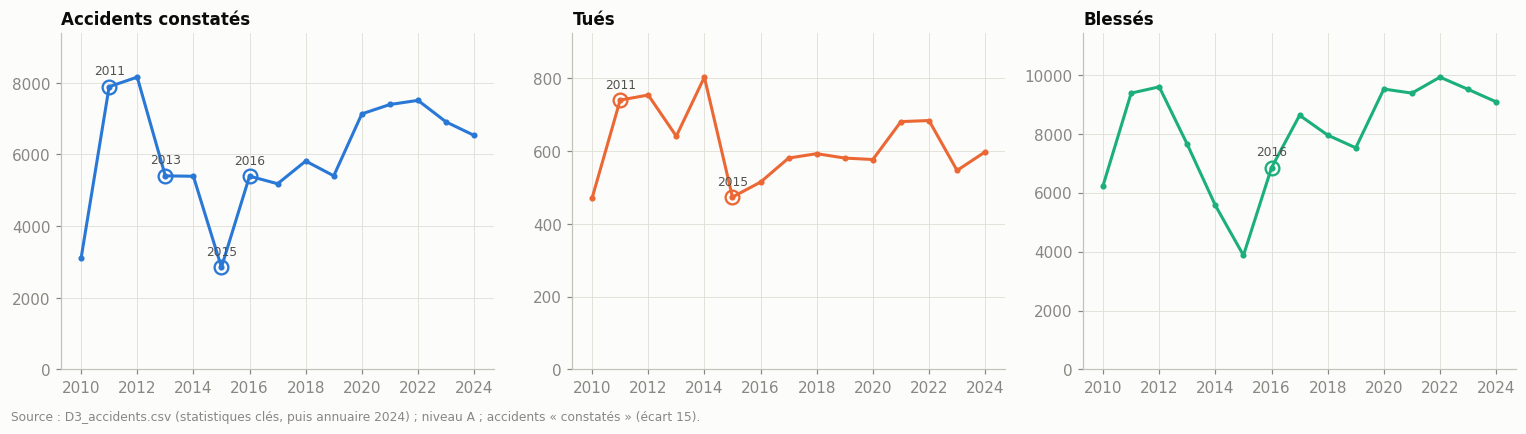

Mesure,Accidents constatés,Blessés,Tués
Année,,,
2010,3101,6241,470
2011,7889,9376,739
2012,8155,9589,753
2013,5401,7636,640
2014,5390,5565,802
2015,2851,3871,473
2016,5393,6846,514
2017,5181,8624,580
2018,5814,7951,592


Catégorie,Accidents constatés,Blessés,Tués
Année,,,
2011,154.4,50.2,57.2
2012,3.4,2.3,1.9
2013,-33.8,-20.4,-15.0
2014,-0.2,-27.1,25.3
2015,-47.1,-30.4,-41.0
2016,89.2,76.9,8.7
2017,-3.9,26.0,12.8
2018,12.2,-7.8,2.1
2019,-7.1,-5.4,-2.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
for ax, couleur, m in zip(axes, SERIES, MESURES):
    ax.plot(d3.index, d3[m], color=couleur, marker="o", markersize=3)
    for an in annees_atypiques(f"Variation annuelle : accidents, tués, blessés ({m})"):
        ax.plot(an, d3.at[an, m], "o", ms=9, mfc="none", mec=couleur, mew=1.5)
        ax.annotate(str(an), (an, d3.at[an, m]), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8, color=ENCRE_2)
    ax.set_ylim(0, d3[m].max() * 1.15); axe_annees(ax); ax.set_title(m, fontsize=11)
fig.tight_layout()
pied(fig, "Source : D3_accidents.csv (statistiques clés, puis annuaire 2024) ; niveau A ; accidents « constatés » (écart 15).")
plt.show()
display(d3.astype(int))
display(serie("Variation annuelle : accidents, tués, blessés"))

## Tués et blessés pour 100 accidents (O2-05, O2-06)

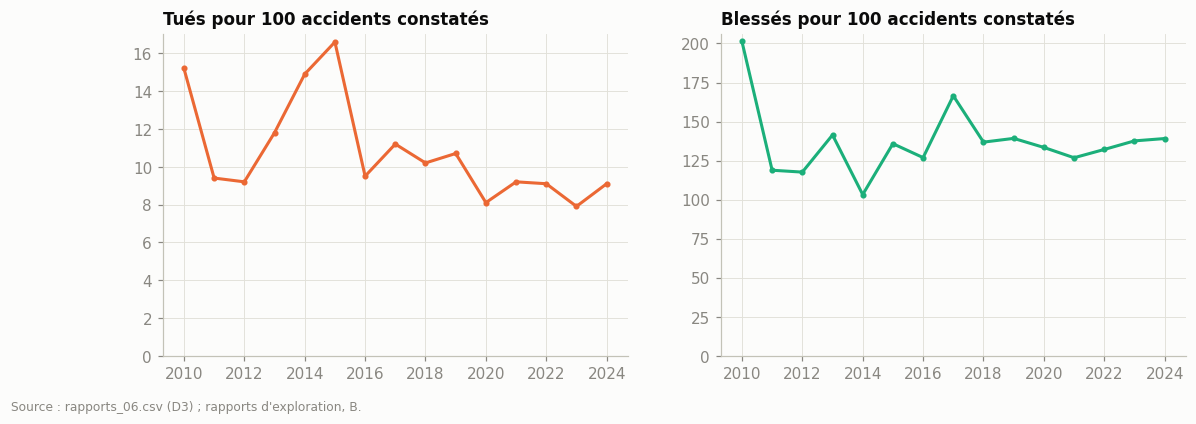

,Tués pour 100 accidents,Blessés pour 100 accidents
Année,,
2010,15.2,201.3
2011,9.4,118.8
2012,9.2,117.6
2013,11.8,141.4
2014,14.9,103.2
2015,16.6,135.8
2016,9.5,126.9
2017,11.2,166.5
2018,10.2,136.8


In [4]:
o205, o206 = serie("Tués pour 100 accidents"), serie("Blessés pour 100 accidents")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(o205.index, o205.iloc[:, 0], color=SERIES[1], marker="o", markersize=3); a1.set_title("Tués pour 100 accidents constatés", fontsize=11)
a2.plot(o206.index, o206.iloc[:, 0], color=SERIES[2], marker="o", markersize=3); a2.set_title("Blessés pour 100 accidents constatés", fontsize=11)
for a in (a1, a2):
    a.set_ylim(bottom=0); axe_annees(a)
pied(fig, "Source : rapports_06.csv (D3) ; rapports d'exploration, B.")
plt.show()
display(pd.concat({"Tués pour 100 accidents": o205.iloc[:, 0], "Blessés pour 100 accidents": o206.iloc[:, 0]}, axis=1))

## Taux par habitant et par véhicule (O2-02, O2-03, O2-04)

Point plein : population de recensement (B) ; point creux : population projetée (C, R-06). Tués pour 10 000 véhicules : bande des bornes du parc estimé (C).

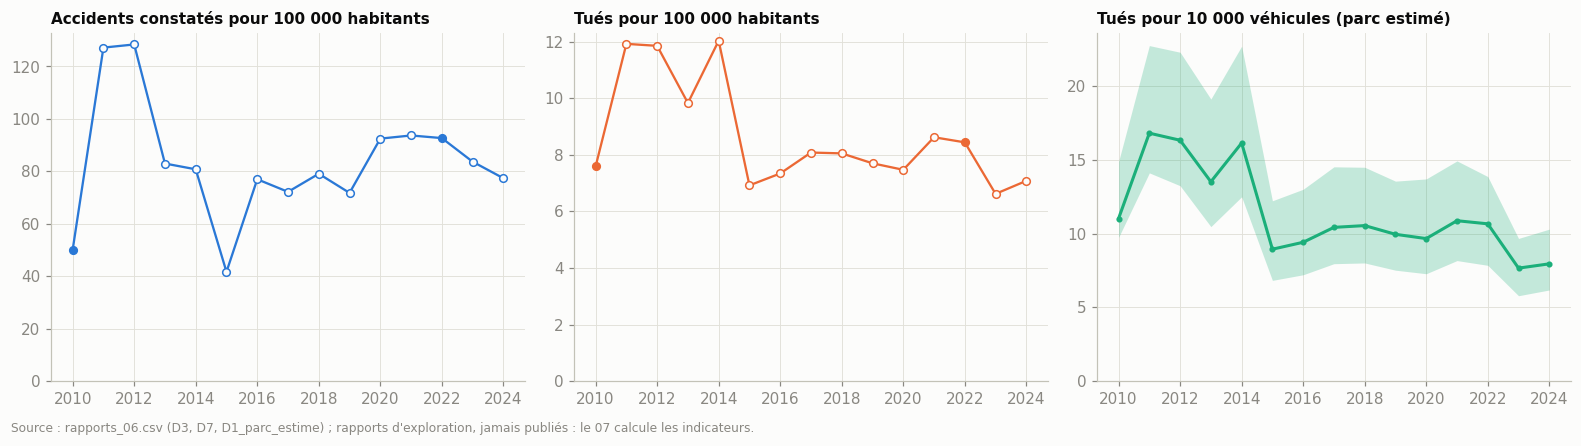

,Accidents constatés pour 100 000 habitants,Tués pour 100 000 habitants,Tués pour 10 000 véhicules,… borne basse,… borne haute
Année,,,,,
2010,50.1,7.59,11.02,9.74,14.87
2011,127.2,11.92,16.80,14.11,22.73
2012,128.4,11.85,16.32,13.24,22.28
2013,83.0,9.83,13.51,10.47,19.11
2014,80.8,12.03,16.13,12.49,22.69
2015,41.7,6.92,8.94,6.83,12.22
2016,77.0,7.34,9.41,7.21,13.00
2017,72.2,8.08,10.42,7.96,14.52
2018,79.1,8.05,10.54,8.01,14.49


In [5]:
taux = {"Accidents constatés pour 100 000 habitants": SERIES[0], "Tués pour 100 000 habitants": SERIES[1]}
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
tableau = {}
for ax, (nom, couleur) in zip(axes, taux.items()):
    r = rapport(nom).assign(Année=lambda d: d["Année"].astype(int)).set_index("Année")
    ax.plot(r.index, r["Valeur"], color=couleur, linewidth=1.5)
    for niv, plein in (("B", True), ("C", False)):
        s = r[r["Niveau"] == niv]
        ax.plot(s.index, s["Valeur"], "o", ms=5, color=couleur, mfc=couleur if plein else SURFACE, linestyle="none")
    ax.set_ylim(bottom=0); axe_annees(ax); ax.set_title(nom, fontsize=10)
    tableau[nom] = r["Valeur"]
r = rapport("Tués pour 10 000 véhicules").assign(Année=lambda d: d["Année"].astype(int)).set_index("Année")
axes[2].fill_between(r.index, r["Borne basse"], r["Borne haute"], color=SERIES[2], alpha=0.25, linewidth=0)
axes[2].plot(r.index, r["Valeur"], color=SERIES[2], marker="o", markersize=3)
axes[2].set_ylim(bottom=0); axe_annees(axes[2]); axes[2].set_title("Tués pour 10 000 véhicules (parc estimé)", fontsize=10)
tableau["Tués pour 10 000 véhicules"] = r["Valeur"]
tableau["… borne basse"], tableau["… borne haute"] = r["Borne basse"], r["Borne haute"]
fig.tight_layout()
pied(fig, "Source : rapports_06.csv (D3, D7, D1_parc_estime) ; rapports d'exploration, jamais publiés : le 07 calcule les indicateurs.")
plt.show()
display(pd.DataFrame(tableau))

## Repères de l'OMS, 2021 (SE-03)

Un repère, jamais une correction des tués déclarés (04 §6). À gauche, en nombre ; à droite, en taux estimé pour 100 000 habitants, face au taux déclaré de 2021.

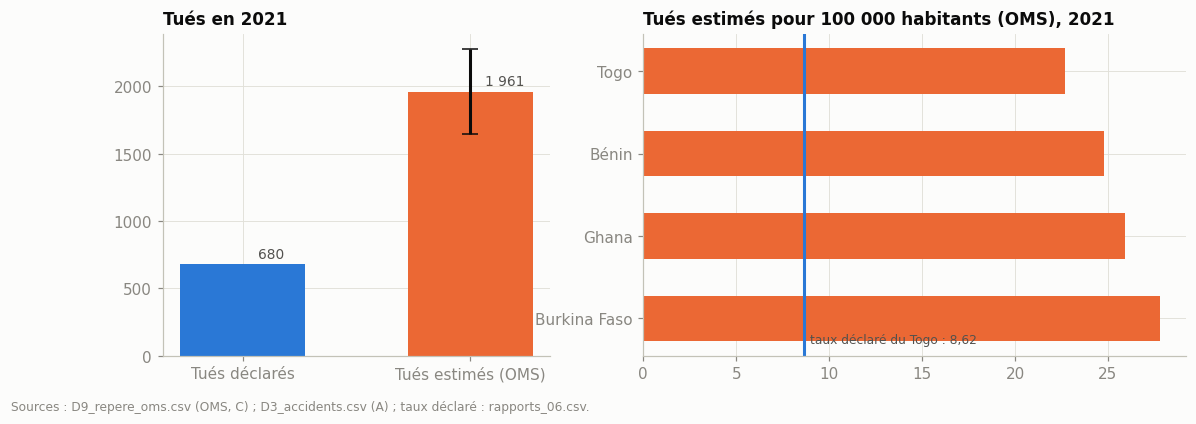

,Indicateur,Pays,Valeur,Borne basse,Borne haute,Niveau
0,Tués estimés pour 100 000 habitants,GHA,25.9,NaN,NaN,C
1,Tués estimés pour 100 000 habitants,BFA,27.8,NaN,NaN,C
2,Tués estimés pour 100 000 habitants,BEN,24.8,NaN,NaN,C
3,Tués estimés pour 100 000 habitants,TGO,22.7,NaN,NaN,C
4,"Tués estimés par l'OMS (repère SE-03, jamais une correction des tués déclarés)",TGO,1961.0,1644.0,2277.0,C


In [6]:
oms = lire("D9_repere_oms")
est = oms[oms["Unité"] == "tués"].iloc[0]
declares = d3.at[2021, "Tués"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.4]})
a1.bar(["Tués déclarés", "Tués estimés (OMS)"], [declares, est["Valeur"]], color=[SERIES[0], SERIES[1]], width=0.55)
a1.errorbar(1, est["Valeur"], yerr=[[est["Valeur"] - est["Borne basse"]], [est["Borne haute"] - est["Valeur"]]], color=ENCRE, capsize=5)
for x, v in enumerate([declares, est["Valeur"]]):
    a1.annotate(f"{v:,.0f}".replace(",", " "), (x, v), xytext=(10, 4), textcoords="offset points", fontsize=9, color=ENCRE_2)
a1.set_title("Tués en 2021", fontsize=11)
pays = oms[oms["Unité"] != "tués"].set_index("Pays")["Valeur"].reindex(["TGO", "BEN", "GHA", "BFA"])
a2.barh(["Togo", "Bénin", "Ghana", "Burkina Faso"], pays.values, color=SERIES[1], height=0.55)
t21 = rapport("Tués pour 100 000 habitants").assign(Année=lambda d: d["Année"].astype(int)).set_index("Année").at[2021, "Valeur"]
a2.axvline(t21, color=SERIES[0], linewidth=2)
a2.annotate(f"taux déclaré du Togo : {t21:.2f}".replace(".", ","), (t21, 3.3), xytext=(4, 0), textcoords="offset points", fontsize=8, color=ENCRE_2)
a2.invert_yaxis(); a2.set_title("Tués estimés pour 100 000 habitants (OMS), 2021", fontsize=11)
pied(fig, "Sources : D9_repere_oms.csv (OMS, C) ; D3_accidents.csv (A) ; taux déclaré : rapports_06.csv.")
plt.show()
display(oms[["Indicateur", "Pays", "Valeur", "Borne basse", "Borne haute", "Niveau"]])

## Tués par type d'usager, 2021 (O2-09)

Profil de l'OMS, en C. La comparaison avec la part des motos dans le parc serait O2-08, non calculable (04 §8) : elle n'est pas faite.

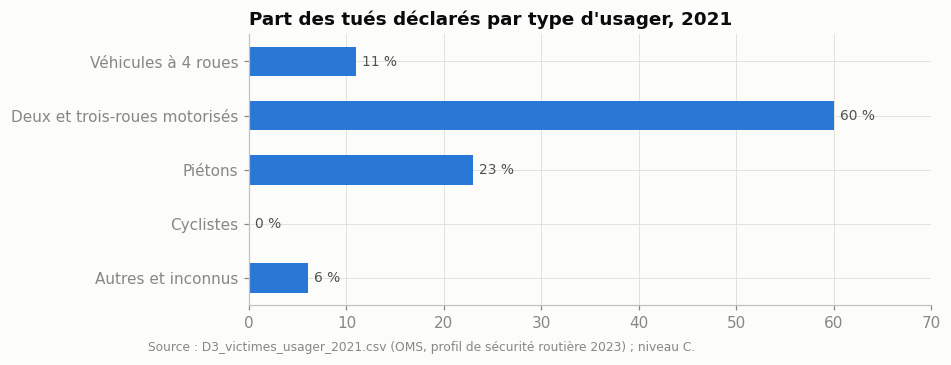

Type d'usager
Véhicules à 4 roues              11.0
Deux et trois-roues motorisés    60.0
Piétons                          23.0
Cyclistes                         0.0
Autres et inconnus                6.0
Name: Part des tués déclarés (%), dtype: float64

In [7]:
u = lire("D3_victimes_usager_2021").set_index("Type d'usager")["Part des tués déclarés (%)"]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(u.index, u.values, color=SERIES[0], height=0.55)
for y, v in enumerate(u.values):
    ax.annotate(f"{v:g} %", (v, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color=ENCRE_2)
ax.invert_yaxis(); ax.set_xlim(0, 70); ax.set_title("Part des tués déclarés par type d'usager, 2021")
pied(fig, "Source : D3_victimes_usager_2021.csv (OMS, profil de sécurité routière 2023) ; niveau C.")
plt.show()
display(u)

## Signaux de O2 (`signaux_06.csv`)

In [8]:
display(signaux(objectif="O2"))

,Résumé,Niveau,Question transmise
ID,,,
SIG-12,"Variation annuelle : accidents, tués, blessés (Accidents constatés) : variation atypique en 2011, 2013, 2015, 2016. Chronologie la même ...",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-13,"Variation annuelle : accidents, tués, blessés (Tués) : variation atypique en 2011, 2015. Chronologie la même année : aucune",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
SIG-14,"Variation annuelle : accidents, tués, blessés (Blessés) : variation atypique en 2016. Chronologie la même année : 2016 : Adoption de la ...",B,"Le 07 annote ces années ; une date de la chronologie est une coïncidence, pas une cause (H1)."
